In [1]:
# Pisahin dari 1979-2021.csv untuk extract (i guess)?

#data: https://www.investing.com/currencies/usd-idr-historical-data
#data: https://www.kaggle.com/datasets/odins0n/monthly-gold-prices/data

import numpy as np
import pandas as pd
import sklearn
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from prophet import Prophet

from scipy import stats

MAX_TAHUN = 2021
MIN_TAHUN = 1988

PREDIKSI_MAX = 2021 + 2021 - 1988 + 1 + 50
INTERVAL = PREDIKSI_MAX - MAX_TAHUN
RANGE = range(MIN_TAHUN, PREDIKSI_MAX)

print("Berhasil")

Importing plotly failed. Interactive plots will not work.


Berhasil


In [2]:
ORIGINAL_GOLD_FILE = "1979-2021.csv"

EXTRACTED_INDONESIA_GOLD = "indonesia_gold.csv"

raw_d = pd.read_csv(ORIGINAL_GOLD_FILE)
indo_raw = raw_d[["Date", "Indonesia(IDR)"]].copy()

indo_raw["Date"] = pd.to_datetime(indo_raw['Date'], format='%d-%m-%Y')
indo_raw["Tahun"] = indo_raw["Date"].dt.year
indo_raw["Bulan"] = indo_raw["Date"].dt.month

indo_raw = indo_raw.drop(columns=['Date'])

cols = list(indo_raw.columns)
cols.remove("Tahun"), cols.remove("Bulan")
cols = ["Tahun", "Bulan"] + cols

indo_raw = indo_raw[cols]
indo_raw = indo_raw.rename(columns={"Indonesia(IDR)": "Harga Emas"})

In [3]:
# Truncate to fix how many are those shit idk
indo_raw = indo_raw[indo_raw["Tahun"] >= MIN_TAHUN].reset_index(drop=True)
print(indo_raw)

     Tahun  Bulan  Harga Emas
0     1988      1    780269.1
1     1988      2    708952.9
2     1988      3    755387.8
3     1988      4    748498.8
4     1988      5    775606.3
..     ...    ...         ...
398   2021      3  24562502.0
399   2021      4  25533702.8
400   2021      5  27131285.3
401   2021      6  25565673.6
402   2021      7  26404909.4

[403 rows x 3 columns]


In [4]:
CONVERSION_RATE_FILE = "USD_IDR Historical Data.csv"

raw_conv = pd.read_csv(CONVERSION_RATE_FILE)
raw_conv = raw_conv.drop(columns=["Price", "High", "Low", "Vol.", "Change %"])
raw_conv["Date"] = pd.to_datetime(raw_conv["Date"], format="%m/%d/%Y")
raw_conv["Tahun"] = raw_conv["Date"].dt.year
raw_conv["Bulan"] = raw_conv["Date"].dt.month
raw_conv = raw_conv.rename(columns={"Open": "Rupiah"})

cols = ["Tahun", "Bulan", "Rupiah"]
raw_conv = raw_conv[cols].iloc[::-1].reset_index(drop=True)

raw_conv["Rupiah"] = raw_conv["Rupiah"].str.replace(",","").astype(float)

print(raw_conv)

     Tahun  Bulan   Rupiah
0     1988      1   1660.0
1     1988      2   1660.0
2     1988      3   1660.0
3     1988      4   1667.0
4     1988      5   1671.0
..     ...    ...      ...
392   2021      8  14465.0
393   2021      9  14265.0
394   2021     10  14310.0
395   2021     11  14185.0
396   2021     12  14344.0

[397 rows x 3 columns]


In [5]:
# Gabungin semua datanya
dataset = pd.merge(indo_raw, raw_conv, on=["Tahun", "Bulan"], how="outer")

# forward fill
dataset = dataset.ffill()

print(dataset)

     Tahun  Bulan  Harga Emas   Rupiah
0     1988      1    780269.1   1660.0
1     1988      2    708952.9   1660.0
2     1988      3    755387.8   1660.0
3     1988      4    748498.8   1667.0
4     1988      5    775606.3   1671.0
..     ...    ...         ...      ...
403   2021      8  26404909.4  14465.0
404   2021      9  26404909.4  14265.0
405   2021     10  26404909.4  14310.0
406   2021     11  26404909.4  14185.0
407   2021     12  26404909.4  14344.0

[408 rows x 4 columns]


In [6]:
# Buat model OLS

# Hanya bergantung pada waktu
model_tahun = smf.ols(formula="Q('Harga Emas') ~ Tahun", data=dataset).fit()
model_bulan = smf.ols(formula="Q('Harga Emas') ~ Tahun + C(Bulan)", data=dataset).fit()

print("Tahun vs Bulan (AIC): ", model_tahun.aic - model_bulan.aic)
print("Tahun vs Bulan (BIC): ", model_tahun.bic - model_bulan.bic)
# Maka tahun lebih bagus, kita gunakan tahun TANPA harus pakai bulan

print("Hasil berdasarkan tahun: ", model_tahun.summary())

# Model rupiah
model_rupiah = smf.ols(formula="Rupiah ~ Tahun", data=dataset).fit()

# Hanya bergantung pada konversi USD
model_konv = smf.ols(formula="Q('Harga Emas') ~ Q('Rupiah')", data=dataset).fit()

print("Hasil berdasarkan rupiah: ", model_konv.summary())

# Bergantung pada waktu dan konversi USD
model_multi = smf.ols(formula="Q('Harga Emas') ~ Rupiah + Tahun", data=dataset).fit()

print("Hasil gabungan: ", model_multi.summary())

print("Tahun vs Rupiah (AIC): ", model_tahun.aic - model_multi.aic)
print("Tahun vs Rupiah (BIC): ", model_tahun.bic - model_multi.bic)
# Karena positif, kita pilih model MULTI!

# Cek multikolinearitas
model_konv_rupiah = smf.ols(formula="Q('Harga Emas') ~ Q('Rupiah')", data=dataset).fit()
print("Model konv_rupiah: ", model_konv_rupiah.summary())

# prediksi untuk tahun ke-2022 sampai 2045
# model_tahun.predict({"Tahun": range(2022, 2045+1)})
# model_konv.predict({"Tahun": range(2022, 2045+1)})
predict_ols = model_tahun.predict({"Tahun": RANGE})

total_ols = predict_ols

print(total_ols)

Tahun vs Bulan (AIC):  -19.968885623118695
Tahun vs Bulan (BIC):  -64.09282454156346
Hasil berdasarkan tahun:                              OLS Regression Results                            
Dep. Variable:        Q('Harga Emas')   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     2692.
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          3.04e-181
Time:                        18:04:53   Log-Likelihood:                -6636.0
No. Observations:                 408   AIC:                         1.328e+04
Df Residuals:                     406   BIC:                         1.328e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [7]:
# Buat model Analisis Deret Waktu menggunakan ARIMA
# Yang endogen saja, P > |z| sudah bagus
arima_rupiah = ARIMA(dataset['Rupiah'], order=(1, 1, 1), trend='t').fit()

my_arima_model = ARIMA(dataset['Harga Emas'], order=(1, 1, 1), trend='t').fit()
print(my_arima_model.summary())

# Buat model Analisis Deret Waktu menggunakan ARIMAX (X = dari USD)
arima_multi = ARIMA(
    endog=dataset['Harga Emas'],
    exog=dataset['Rupiah'],
    order=(1, 1, 1),
    trend='t',
).fit()

print(arima_multi.summary())

total_arima = pd.concat([dataset['Harga Emas'][::12], arima_multi.forecast(INTERVAL, exog=arima_rupiah.forecast(INTERVAL))])
total_arima = total_arima.reset_index(drop=True)

print(total_arima)

                               SARIMAX Results                                
Dep. Variable:             Harga Emas   No. Observations:                  408
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5951.648
Date:                Tue, 16 Jun 2026   AIC                          11911.297
Time:                        18:04:53   BIC                          11927.332
Sample:                             0   HQIC                         11917.643
                                - 408                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          6.296e+04   2.09e+04      3.011      0.003     2.2e+04    1.04e+05
ar.L1          0.5056      0.101      5.000      0.000       0.307       0.704
ma.L1         -0.6448      0.089     -7.249      0.0

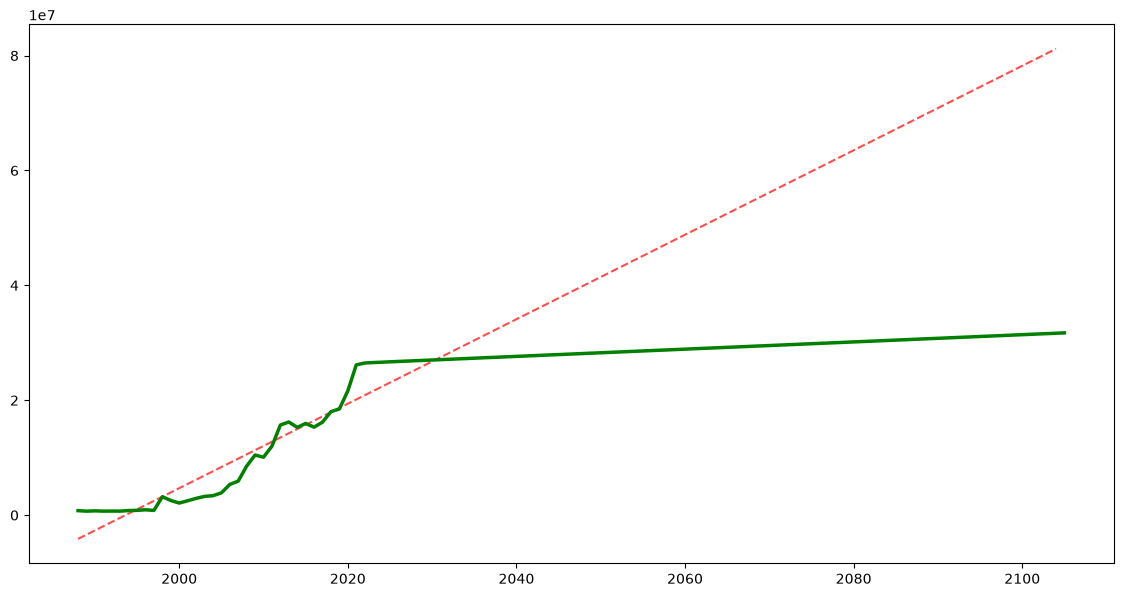

In [8]:
plt.figure(figsize=(14, 7)) # Bikin kanvas gede biar mantap

# B. Plot Garis OLS (Warna Merah Putus-putus)
# Kita gabungin garis historis dan masa depan biar keliatan kaku-nya OLS dari ujung ke ujung
plt.plot(range(MIN_TAHUN, MIN_TAHUN + len(total_ols)), total_ols, color='red', linestyle='--', alpha=0.7)

plt.plot(range(MIN_TAHUN, MIN_TAHUN + len(total_arima)), total_arima, color='green', linewidth=2.5, label='Forecast ARIMA (Fleksibel & Nanjak)')

